# Accuracy and Efficiency Figures

This notebook selects the trained MLP and KAN models, evaluates them on the far field, and saves two figures.

In [22]:
import pandas as pd

In [23]:
import os
import sys
from datetime import datetime
import itertools

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns_infinite
import infinite
reload(plotting)
reload(pinns_infinite)
reload(infinite)
from figure_far_field import plot_far_field
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
from pinns_infinite import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns_infinite import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
class Sine(nn.Module):
    def __init__(self):
        super(Sine, self).__init__()

    def forward(self, x):
        return torch.sin(x)


## Experiment Summary

In [24]:
 
mlp_results_dir = "results_accuracy_efficiency_2026-09-20_17-10-10"
kan_results_dir = "results_accuracy_efficiency_2026-09-20_14-13-31"

mlp_csv = os.path.join(
    mlp_results_dir,
    "summary_metrics.csv"
)

kan_csv = os.path.join(
    kan_results_dir,
    "summary_metrics.csv"
)

df_mlp = pd.read_csv(mlp_csv)
df_kan = pd.read_csv(kan_csv)

df_mlp.columns = df_mlp.columns.str.strip()
df_kan.columns = df_kan.columns.str.strip()

# Global mean error
df_mlp["err_global_mean"] = df_mlp[
    ["err_u_global", "err_k_global"]
].mean(axis=1)

df_kan["err_global_mean"] = df_kan[
    ["err_u_global", "err_k_global"]
].mean(axis=1)

target_error = 1e-2

mlp_csv = os.path.join(
    mlp_results_dir,
    "summary_metrics.csv"
)

kan_csv = os.path.join(
    kan_results_dir,
    "summary_metrics.csv"
)

 
# Combine both experiments
df = pd.concat(
    [df_mlp, df_kan],
    ignore_index=True
)

print(f"MLP runs: {len(df_mlp)}")
print(f"KAN runs: {len(df_kan)}")
print(f"Total runs: {len(df)}")

MLP runs: 9
KAN runs: 9
Total runs: 18


## Trade-off Figure

In [25]:
import importlib
import figure_tradeoff

importlib.reload(figure_tradeoff)

# Get the updated function
plot_tradeoff = figure_tradeoff.plot_tradeoff

# Prepare the experiment-summary data
_df_mlp = df[df["model_type"] == "MLP"].copy()
_df_kan = df[df["model_type"] == "KAN"].copy()
df_mlp = _df_mlp
df_kan = _df_kan

## Model Selection

In [26]:
# =========================================================
# Select Models
# =========================================================
# Use the optimal configuration found by Optuna in 02_hyperparameter_tunning:
# MLP -> L=3, width=90 (Sine, lr=1e-3); KAN -> L=3, width=25 (grid=5, spline_order=4, lr=1e-2)
optimal_mlp_layers, optimal_mlp_units = 3, 90
optimal_kan_layers, optimal_kan_units = 3, 25

# ---------------------------------------------------------
# MLP
# ---------------------------------------------------------

mlp_match = df_mlp[
    (df_mlp["hidden_layers"] == optimal_mlp_layers)
    & (df_mlp["hidden_units"] == optimal_mlp_units)
]
mlp_selected = mlp_match.iloc[0]

# ---------------------------------------------------------
# KAN
# ---------------------------------------------------------

kan_match = df_kan[
    (df_kan["hidden_layers"] == optimal_kan_layers)
    & (df_kan["hidden_units"] == optimal_kan_units)
]
kan_selected = kan_match.iloc[0]


print("\nSelected MLP:")
print(mlp_selected)

print("\nSelected KAN:")
print(kan_selected)


Selected MLP:
model_type                                   MLP
hidden_layers                                  3
hidden_units                                  90
adam_lr                                    0.001
adam_iters                                  2000
lbfgs_iters                                 2000
activation                                Sine()
grid_size                                    NaN
spline_order                                 NaN
sampling                                gaussian
sigma                                        5.5
exp_scale                                    1.0
n_obs_u                                      100
n_obs_k                                      100
n_pde                                       1000
seed                                          42
lambda_pde_scheduler                        True
adaptive_weights                            True
alpha                                          7
update_every                                 100
regul

## Load Selected Models

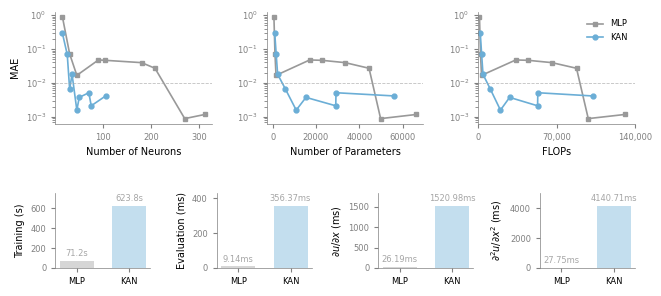

In [34]:
import os
import json
import torch
import torch.nn as nn
import pandas as pd

from torch.utils.flop_counter import FlopCounterMode


# ============================================================
# Paths
# ============================================================

mlp_run_dir = os.path.join(
    mlp_results_dir,
    "MLP",
    str(mlp_selected["timestamp"])
)

kan_run_dir = os.path.join(
    kan_results_dir,
    "KAN",
    str(kan_selected["timestamp"])
)

mlp_model_u_path = os.path.join(mlp_run_dir, "model_u.pt")
mlp_model_k_path = os.path.join(mlp_run_dir, "model_k.pt")
kan_model_u_path = os.path.join(kan_run_dir, "model_u.pt")
kan_model_k_path = os.path.join(kan_run_dir, "model_k.pt")


# ============================================================
# Load configurations and trained models
# ============================================================

with open(os.path.join(mlp_run_dir, "run_metrics_and_config.json"), "r") as f:
    mlp_config = json.load(f)

# Rebuild with the activation actually used for training, not a hardcoded one
mlp_activation = Sine() if mlp_config["activation"].startswith("Sine") else nn.Tanh()
model_u_mlp, model_k_mlp = build_models(
    device=device,
    hidden_layers=mlp_config["hidden_layers"],
    hidden_units=mlp_config["hidden_units"],
    activation=mlp_activation,
)
model_u_mlp.load_state_dict(torch.load(mlp_model_u_path, map_location=device))
model_k_mlp.load_state_dict(torch.load(mlp_model_k_path, map_location=device))
model_u_mlp.eval()
model_k_mlp.eval()

with open(os.path.join(kan_run_dir, "run_metrics_and_config.json"), "r") as f:
    kan_config = json.load(f)

model_u_kan, model_k_kan = build_models_KAN(
    device=device,
    hidden_layers=kan_config["hidden_layers"],
    hidden_units=kan_config["hidden_units"],
    grid_size=kan_config["grid_size"],
    spline_order=kan_config["spline_order"],
)
model_u_kan.load_state_dict(torch.load(kan_model_u_path, map_location=device))
model_k_kan.load_state_dict(torch.load(kan_model_k_path, map_location=device))
model_u_kan.eval()
model_k_kan.eval()


# ============================================================
# Cost definitions
# ============================================================

INPUT_SIZE = 2
OUTPUT_SIZE = 1


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_parameters_pair(model_u, model_k):
    return count_parameters(model_u) + count_parameters(model_k)


def measure_flops(model):
    dummy_input = torch.randn((1, INPUT_SIZE), device=device)
    flop_counter = FlopCounterMode(display=False)
    with flop_counter:
        model(dummy_input)
    return flop_counter.get_total_flops()


def measure_flops_pair(model_u, model_k):
    return measure_flops(model_u) + measure_flops(model_k)


def mlp_connection_sum(hidden_layers, hidden_units):
    return (
        INPUT_SIZE * hidden_units
        + hidden_layers * hidden_units**2
        + hidden_units * OUTPUT_SIZE
    )


def kan_connection_sum(hidden_layers, hidden_units):
    return (
        INPUT_SIZE * hidden_units
        + max(hidden_layers - 1, 0) * hidden_units**2
        + hidden_units * OUTPUT_SIZE
    )


def mlp_theoretical_flops(hidden_layers, hidden_units):
    return 2 * mlp_connection_sum(hidden_layers, hidden_units)


def mlp_theoretical_flops_pair(hidden_layers, hidden_units):
    return 2 * mlp_theoretical_flops(hidden_layers, hidden_units)


def kan_theoretical_flops(hidden_layers, hidden_units, grid_size, spline_order):
    return 2 * (grid_size + spline_order + 1) * kan_connection_sum(
        hidden_layers,
        hidden_units,
    )


def kan_theoretical_flops_pair(hidden_layers, hidden_units, grid_size, spline_order):
    return 2 * kan_theoretical_flops(
        hidden_layers,
        hidden_units,
        grid_size,
        spline_order,
    )


def mlp_theoretical_parameters(hidden_layers, hidden_units):
    return (
        (INPUT_SIZE + 1) * hidden_units
        + hidden_layers * hidden_units * (hidden_units + 1)
        + (hidden_units + 1) * OUTPUT_SIZE
    )


def mlp_theoretical_parameters_pair(hidden_layers, hidden_units):
    return 2 * mlp_theoretical_parameters(hidden_layers, hidden_units)


def kan_theoretical_parameters(hidden_layers, hidden_units, grid_size, spline_order):
    return (grid_size + spline_order + 2) * kan_connection_sum(
        hidden_layers,
        hidden_units,
    )


def kan_theoretical_parameters_pair(hidden_layers, hidden_units, grid_size, spline_order):
    return 2 * kan_theoretical_parameters(
        hidden_layers,
        hidden_units,
        grid_size,
        spline_order,
    )


# ============================================================
# Measure all nine configurations for each architecture
# ============================================================

def measure_configuration_costs(frame, model_type):
    measured_flops = []
    theoretical_flops = []
    measured_parameters = []
    theoretical_parameters = []

    for _, row in frame.iterrows():
        hidden_layers = int(row["hidden_layers"])
        hidden_units = int(row["hidden_units"])

        if model_type == "MLP":
            model_u, model_k = build_models(
                device=device,
                hidden_layers=hidden_layers,
                hidden_units=hidden_units,
                activation=nn.Tanh(),
            )
            parameters = count_parameters_pair(model_u, model_k)
            flops = measure_flops_pair(model_u, model_k)
            theory_flops = mlp_theoretical_flops_pair(hidden_layers, hidden_units)
            theory_parameters = mlp_theoretical_parameters_pair(hidden_layers, hidden_units)
        else:
            grid_size = int(row["grid_size"])
            spline_order = int(row["spline_order"])
            model_u, model_k = build_models_KAN(
                device=device,
                hidden_layers=hidden_layers,
                hidden_units=hidden_units,
                grid_size=grid_size,
                spline_order=spline_order,
            )
            parameters = count_parameters_pair(model_u, model_k)
            flops = measure_flops_pair(model_u, model_k)
            theory_flops = kan_theoretical_flops_pair(
                hidden_layers,
                hidden_units,
                grid_size,
                spline_order,
            )
            theory_parameters = kan_theoretical_parameters_pair(
                hidden_layers,
                hidden_units,
                grid_size,
                spline_order,
            )

        measured_parameters.append(parameters)
        theoretical_parameters.append(theory_parameters)
        measured_flops.append(flops)
        theoretical_flops.append(theory_flops)

    return measured_parameters, theoretical_parameters, measured_flops, theoretical_flops


(
    df_mlp["parameters"],
    df_mlp["theoretical_parameters"],
    df_mlp["flop_counter_flops"],
    df_mlp["theoretical_flops"],
) = measure_configuration_costs(df_mlp, "MLP")

(
    df_kan["parameters"],
    df_kan["theoretical_parameters"],
    df_kan["flop_counter_flops"],
    df_kan["theoretical_flops"],
) = measure_configuration_costs(df_kan, "KAN")


 

plot_tradeoff(
    df_mlp,
    df_kan,
    output_dir="figures",

    target_error=target_error,)

In [29]:
# =========================================================
# Print the nine configuration costs
# =========================================================

for model_name, frame in (("MLP", df_mlp), ("KAN", df_kan)):
    columns = [
        "hidden_layers",
        "hidden_units",
        "parameters",
        "flop_counter_flops",
    ]
    if model_name == "KAN":
        columns.insert(2, "grid_size")
        columns.insert(3, "spline_order")

    report = frame[columns].copy()
    report.insert(0, "model", model_name)
    report = report.rename(columns={
        "hidden_layers": "layers",
        "hidden_units": "width",
        "flop_counter_flops": "FLOPs",
    })
    print(f"\n{model_name} configuration costs:")
    print(report.to_string(index=False))


MLP configuration costs:
model  layers  width  parameters  FLOPs
  MLP       1     15         602   1080
  MLP       1     90       17102  33480
  MLP       1    104       22674  44512
  MLP       2     15        1082   1980
  MLP       2     90       33482  65880
  MLP       2    104       44514  87776
  MLP       3     15        1562   2880
  MLP       3     90       49862  98280
  MLP       3    104       66354 131040

KAN configuration costs:
model  layers  width  grid_size  spline_order  parameters  FLOPs
  KAN       1     15        5.0           4.0         990   1800
  KAN       1     25        5.0           4.0        1650   3000
  KAN       1     35        5.0           4.0        2310   4200
  KAN       2     15        5.0           4.0        5940  10800
  KAN       2     25        5.0           4.0       15400  28000
  KAN       2     35        5.0           4.0       29260  53200
  KAN       3     15        5.0           4.0       10890  19800
  KAN       3     25        

## Far-field Figure


Far-field evaluation
MLP outside MAE: 6.2081e-01
KAN outside MAE: 2.3432e+00

Square-ring MAE
  0–10 : MLP = 3.055e-03    KAN = 2.954e-03
 10–20 : MLP = 2.184e-01    KAN = 1.102e-02
 20–30 : MLP = 5.687e-01    KAN = 4.552e-02
 30–40 : MLP = 6.572e-01    KAN = 3.901e-01
 40–50 : MLP = 6.396e-01    KAN = 1.212e+00
 50–60 : MLP = 6.539e-01    KAN = 1.986e+00
 60–70 : MLP = 6.973e-01    KAN = 2.510e+00
 70–80 : MLP = 6.213e-01    KAN = 2.895e+00
 80–90 : MLP = 6.357e-01    KAN = 3.231e+00
90–100 : MLP = 6.155e-01    KAN = 3.530e+00


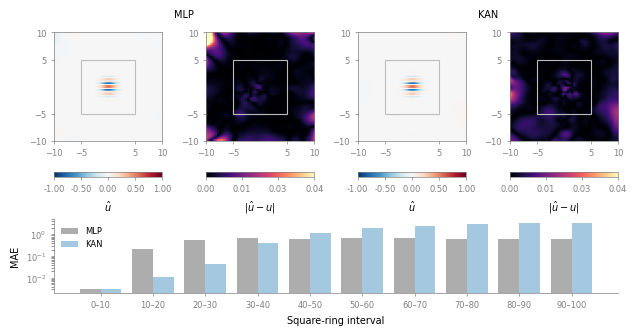

Figure successfully saved to figures/far_field.svg


In [30]:
from figure_far_field import plot_far_field

# Evaluation domain used for predictions and square-ring MAE.
eval_xmin = -100.0
eval_xmax = 100.0
eval_ymin = -100.0
eval_ymax = 100.0
n_grid = 500

x = np.linspace(eval_xmin, eval_xmax, n_grid)
y = np.linspace(eval_ymin, eval_ymax, n_grid)
X, Y = np.meshgrid(x, y)

alpha = mlp_config["pde_alpha"]
beta = mlp_config["pde_beta"]
U = analytical_solution_inf(X, Y, alpha, beta)

X_test = torch.tensor(
    np.column_stack([X.ravel(), Y.ravel()]),
    dtype=torch.float32,
    device=device,
)

model_u_mlp.eval()
model_u_kan.eval()
with torch.no_grad():
    U_pred_mlp = model_u_mlp(X_test).cpu().numpy().reshape(U.shape)
    U_pred_kan = model_u_kan(X_test).cpu().numpy().reshape(U.shape)

outside_mask = (
    (X < -5.0)
    | (X > 5.0)
    | (Y < -5.0)
    | (Y > 5.0)
)

error_mlp = np.abs(U_pred_mlp - U)
error_kan = np.abs(U_pred_kan - U)
print("\n========================================")
print("Far-field evaluation")
print("========================================")
print(f"MLP outside MAE: {np.mean(error_mlp[outside_mask]):.4e}")
print(f"KAN outside MAE: {np.mean(error_kan[outside_mask]):.4e}")

palette = {
    "kan": "#1F77B4",
    "mlp": "#333333",
}

fig, mae_mlp, mae_kan = plot_far_field(
    U_pred_mlp,
    U_pred_kan,
    U,
    x,
    y,
    palette,
    output_dir="figures",
    error_vmax=0.04,
    error_n_ticks=4,
    error_tick_decimals=2,
    mae_decimals=3,
)
